## Filter Out Odd `discharge` Values

__Method:__

It computes the rolling standard deviation with a specified window size. The min_periods parameter ensures that the window is only considered complete when it contains the full number of days.

1. Check for the odd values

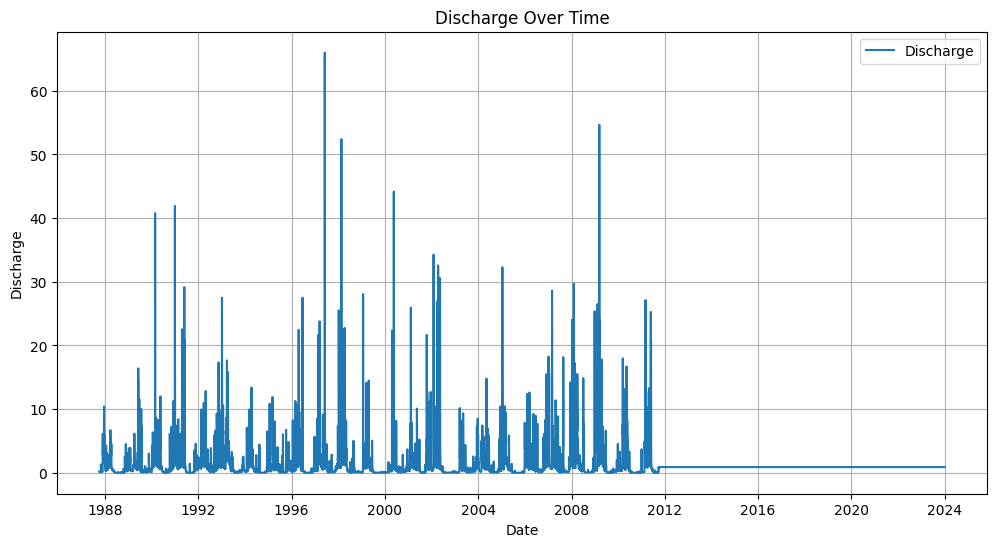

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

def get_file_name(basin_id: str):
    file_name = str(basin_id) + ".csv"

    return "csv_files/" + file_name 

csv_path = get_file_name("04176605")

# Read the CSV file with "date" as an index
df = pd.read_csv(csv_path, index_col='date', parse_dates=True)

# Plot the "discharge" column
plt.figure(figsize=(12, 6))
plt.plot(df['discharge'], label='Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.title('Discharge Over Time')
plt.legend()
plt.grid(True)
plt.show()

2. Process the files and save to a new file

In [6]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Define input and output directories
data_dir = "csv_files"
output_dir = "csv_filtered"

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Parameters for detecting suspicious data
window_size = 14               # Rolling window length (days)
std_threshold = 1e-5           # Threshold for standard deviation

# Process each CSV file
for filename in tqdm(os.listdir(data_dir)):
    if not filename.endswith(".csv"):
        continue
    
    csv_path = os.path.join(data_dir, filename)
    df = pd.read_csv(csv_path)
    
    # Ensure 'discharge' column exists
    if "discharge" not in df.columns:
        continue

    # Compute rolling standard deviation for the 'discharge' column
    rolling_std = df["discharge"].rolling(window=window_size, min_periods=window_size).std()
    
    # For each complete rolling window, if the standard deviation is below the threshold,
    # set the corresponding window of "discharge" values to NaN.
    for i in range(window_size - 1, len(df)):
        if pd.notna(rolling_std.iloc[i]) and rolling_std.iloc[i] < std_threshold:
            start_index = i - window_size + 1
            df.loc[start_index:i, "discharge"] = np.nan
    
    # Save the modified DataFrame in the output directory using the same filename
    output_path = os.path.join(output_dir, filename)
    df.to_csv(output_path, index=False)

print("Processing complete. Filtered CSV files saved to '{}'.".format(output_dir))


100%|██████████| 976/976 [04:51<00:00,  3.35it/s]

Processing complete. Filtered CSV files saved to 'csv_filtered'.


3. Check the new file for odd values

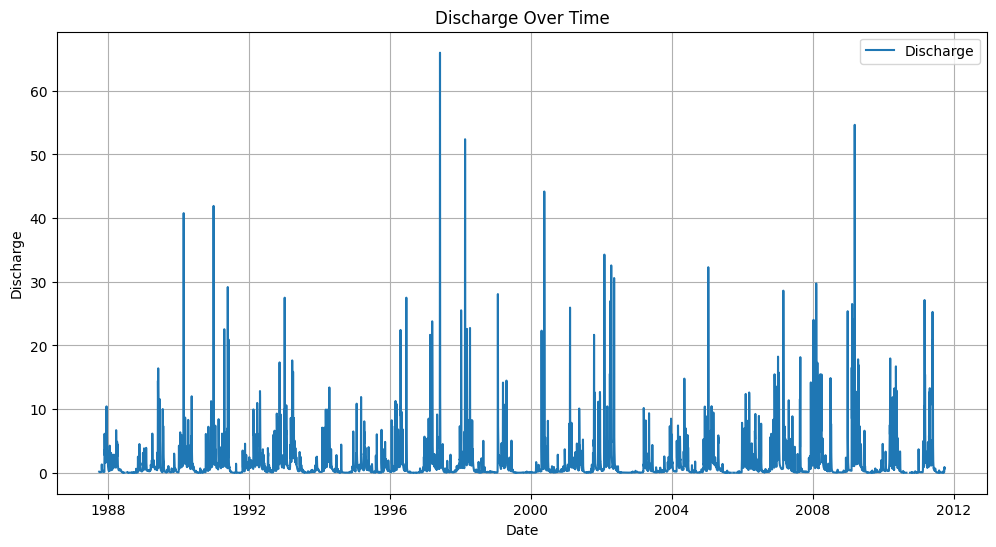

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def get_file_name(basin_id: str):
    file_name = str(basin_id) + ".csv"

    return "csv_filtered/" + file_name 

csv_path = get_file_name("04176605")

# Read the CSV file with "date" as an index
df = pd.read_csv(csv_path, index_col='date', parse_dates=True)

# Plot the "discharge" column
plt.figure(figsize=(12, 6))
plt.plot(df['discharge'], label='Discharge')
plt.xlabel('Date')
plt.ylabel('Discharge')
plt.title('Discharge Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Prepare Metadata for Reference

In [ ]:
import os
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm import tqdm
import geopandas as gpd

# Define paths
csv_dir = "csv_files"         # Folder with CSV files
shp_dir = "shp_wgs84"                # Folder with shapefiles
output_meta = "meta_data.csv"        # Output metadata file

# Initialize list for metadata rows
meta_rows = []

# Define the training period (1981-01-01 to 2010-12-31)
train_start = pd.to_datetime("1981-01-01")
train_end = pd.to_datetime("2010-12-31")

# Loop over each CSV file
for filename in tqdm(os.listdir(csv_dir)):
    if not filename.endswith(".csv"):
        continue

    gauge_id = os.path.splitext(filename)[0]
    csv_path = os.path.join(csv_dir, filename)
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Error reading {csv_path}: {e}")
        continue

    # Make sure 'discharge' exists and convert date column to datetime
    if "discharge" not in df.columns:
        continue
    df["date"] = pd.to_datetime(df["date"], errors='coerce')
    
    # Compute overall metrics
    total_rows = len(df)
    non_nan_rows = df["discharge"].notna().sum()
    coverage = non_nan_rows / total_rows if total_rows > 0 else np.nan
    mean_discharge = df["discharge"].mean()
    var_discharge = df["discharge"].var()
    
    # Filter for training period and compute train metrics
    mask_train = (df["date"] >= train_start) & (df["date"] <= train_end)
    df_train = df.loc[mask_train]
    mean_discharge_train = df_train["discharge"].mean() if not df_train.empty else np.nan
    var_discharge_train = df_train["discharge"].var() if not df_train.empty else np.nan
    
    # Read the corresponding shapefile to compute surface area.
    # Assume shapefile name is gauge_id.shp in the shp_dir folder.
    shp_path = os.path.join(shp_dir, f"{gauge_id}.shp")
    surface_area = np.nan
    ratio_mean_area = np.nan
    if os.path.exists(shp_path):
        try:
            # Read the shapefile with geopandas
            gdf = gpd.read_file(shp_path)
            # Reproject to a metric CRS (EPSG:3395 for example)
            gdf_metric = gdf.to_crs(epsg=3395)
            # Compute total area (in square meters)
            surface_area = gdf_metric["geometry"].area.sum()
            if surface_area > 0:
                ratio_mean_area = mean_discharge / surface_area
        except Exception as e:
            print(f"Error processing shapefile {shp_path}: {e}")
    
    # Append the metadata row for the current gauge
    meta_rows.append({
        "gauge_id": gauge_id,
        "coverage": coverage,
        "surface_ratio": ratio_mean_area,
        "num_rows": non_nan_rows,
        "mean_discharge_train": mean_discharge_train,
        "mean_discharge": mean_discharge,
        "var_discharge_train": var_discharge_train,
        "var_discharge": var_discharge
    })

# Create a DataFrame from metadata rows and save as CSV
meta_df = pd.DataFrame(meta_rows)
meta_df.to_csv(output_meta, index=False)

print(f"Metadata processing complete. Saved to '{output_meta}'.")


100%|██████████| 976/976 [00:17<00:00, 56.42it/s]

Metadata processing complete. Saved to 'meta_data.csv'.


# Inspect the data using metadata

## Discharge Coverage

count    975.000000
mean       0.760999
std        0.356911
min        0.000000
25%        0.532232
50%        1.000000
75%        1.000000
max        1.000000
Name: coverage, dtype: float64


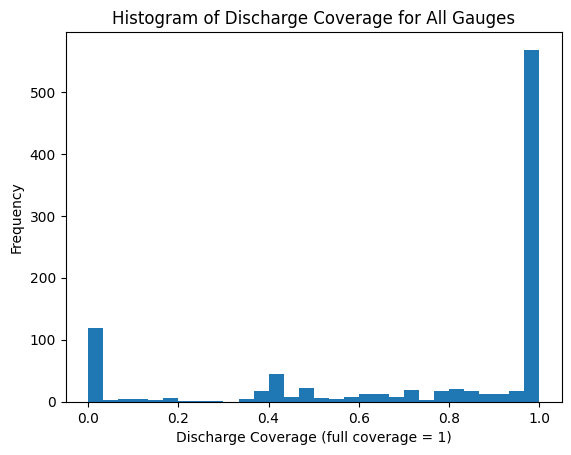

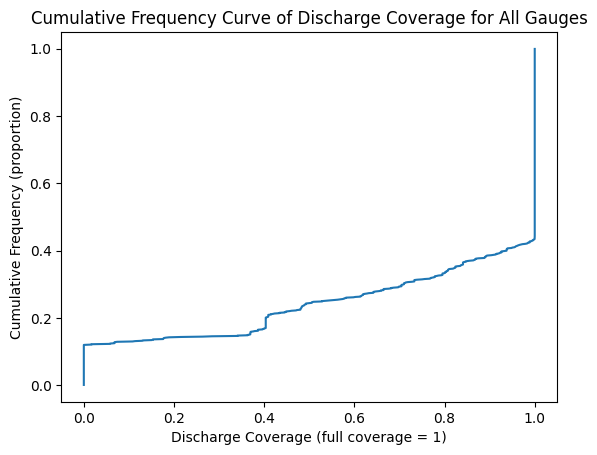

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the metadata CSV file
meta_df = pd.read_csv("meta_data.csv")

# Display summary statistics for the 'coverage' column
print(meta_df["coverage"].describe())

# Plot the histogram of discharge coverage
plt.hist(meta_df["coverage"], bins=30)
plt.xlabel('Discharge Coverage (full coverage = 1)')
plt.ylabel('Frequency')
plt.title('Histogram of Discharge Coverage for All Gauges')
plt.show()

# Sort the coverage values in ascending order
sorted_coverage = meta_df["coverage"].sort_values()

# Calculate the cumulative frequency
cumulative_frequency = sorted_coverage.rank(method='first') / len(sorted_coverage)

# Plot the cumulative frequency curve
plt.plot(sorted_coverage, cumulative_frequency)
plt.xlabel('Discharge Coverage (full coverage = 1)')
plt.ylabel('Cumulative Frequency (proportion)')
plt.title('Cumulative Frequency Curve of Discharge Coverage for All Gauges')
plt.show()


In [14]:
meta_df[meta_df["gauge_id"] == "04176605"]

,gauge_id,coverage,mean discharge / surface area,num_rows,mean_discharge_train,mean_discharge,var_discharge_train,var_discharge
857,04176605,0.823906,NaN,13241,1.349881,1.204328,9.216847,6.256928


In [18]:
meta_df.num_rows

0      16071
1          0
2          0
3          0
4      16071
       ...  
971    16071
972    16071
973    16071
974    16071
975    16071
Name: num_rows, Length: 976, dtype: int64

## Surface Area Ratio

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the metadata CSV file
meta_df = pd.read_csv("meta_data.csv")

# Draw a boxplot of the "surface_ratio" column
plt.figure(figsize=(10, 6))
plt.boxplot(meta_df["surface_ratio"].dropna(), vert=False)
plt.xlabel('Surface Ratio')
plt.title('Boxplot of Surface Ratio')
plt.grid(True)
plt.show()

KeyError: 'surface_ratio'

<Figure size 1000x600 with 0 Axes>

In [ ]:
meta_dfs['surface_ratio']

KeyError: 'surface_ratio'